In [1]:
import numpy as np
import matplotlib.pyplot as plt

## CML "Theta Dynamics"

**Map**: $\theta_{n+1,i} = (f(\theta_{n,i}) + \varepsilon/2(f(\theta_{n,i+1}) + f(\theta_{n,i-1})) \pmod{1}$

**Map**: $f(\theta) = \theta + \omega - \frac{K}{2\pi}\sin(2\pi\theta)$

- $\theta \in [0, 1]$ (angle normalized to unit circle)
- $\omega \in [0,1)$
- $K$ = nonlinearity parameter
- $\varepsilon$ = coupling strength between neighbors

In [2]:
# Setting up parameters
N       = 100   # Number of lattice sites (spatial dimension)
T       = 300   # Number of time steps
omega   = 0.5   
K       = 1   # Nonlinearity parameter (controls chaos)
epsilon = 0.3   # Coupling strength (0 = no coupling, 1 = max coupling)

In [3]:
# Initial conditions
np.random.seed(42)            # Makes the randomness reproducible
theta = np.random.rand(N)     # Each of the 100 sites gets a random starting phase in [0, 1)

In [4]:
# The rotational (circle) map
def rotational_map(theta, omega, K):
    return (theta + omega - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta))

In [5]:
# Storage
history = np.zeros((T, N))
history[0] = theta  # Store initial state in the first row of history

In [6]:
# Time evolution with spatial coupling
for t in range(1, T):
    f_theta  = rotational_map(theta, omega, K)     # Map every site
    f_left   = np.roll(f_theta,  1)                # Left neighbor's mapped phase
    f_right  = np.roll(f_theta, -1)               # Right neighbor's mapped phase
    
    # CML coupling: average with neighbors
    theta = ((1 - epsilon) * f_theta + (epsilon / 2) * (f_left + f_right)) % 1
    
    history[t] = theta

print("Done. history.shape =", history.shape)

Done. history.shape = (300, 100)


In [8]:
print("Min phase:", history.min().round(3))   
print("Max phase:", history.max().round(3))   
print("Sample row (t=0):", history[0, :5])   # Initial conditions
print("Sample row (t=1):", history[1, :5])   # first update

Min phase: 0.0
Max phase: 1.0
Sample row (t=0): [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Sample row (t=1): [0.83426688 0.37222233 0.37664221 0.12087509 0.62390881]


#### Plotting the characteristic graphs

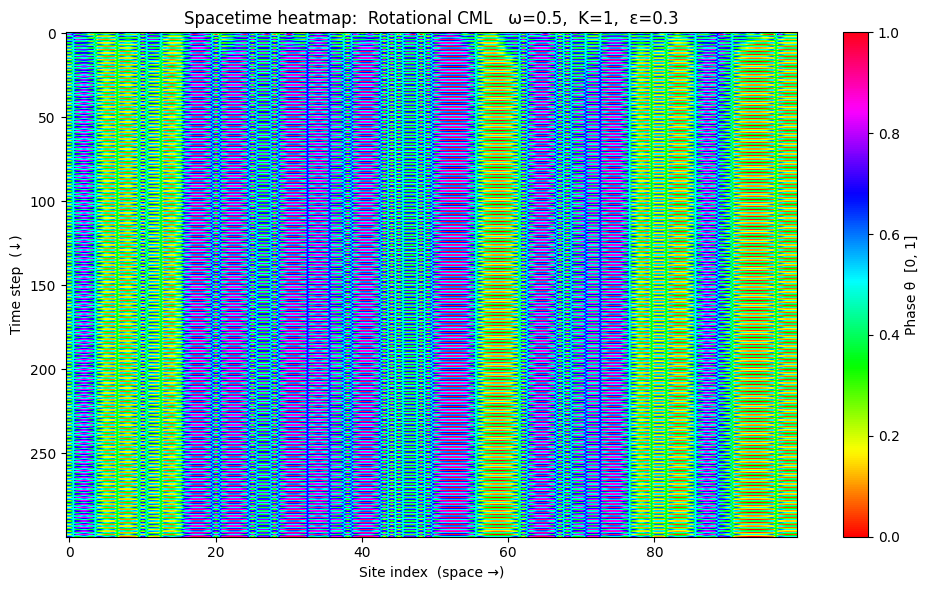

In [ ]:
# Spacetime Heatmap (Spatiotemporal evolution)

plt.figure(figsize=(10, 6))

plt.imshow(history, aspect='auto', cmap='hsv', origin='upper', vmin=0, vmax=1)

plt.colorbar(label='Phase θ  [0, 1]')
plt.xlabel('Site index  (space →)')
plt.ylabel('Time step  (↓)')
plt.title(f'Spacetime heatmap:  Rotational CML   ω={omega},  K={K},  ε={epsilon}')
plt.tight_layout()

plt.savefig("Spacetime_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

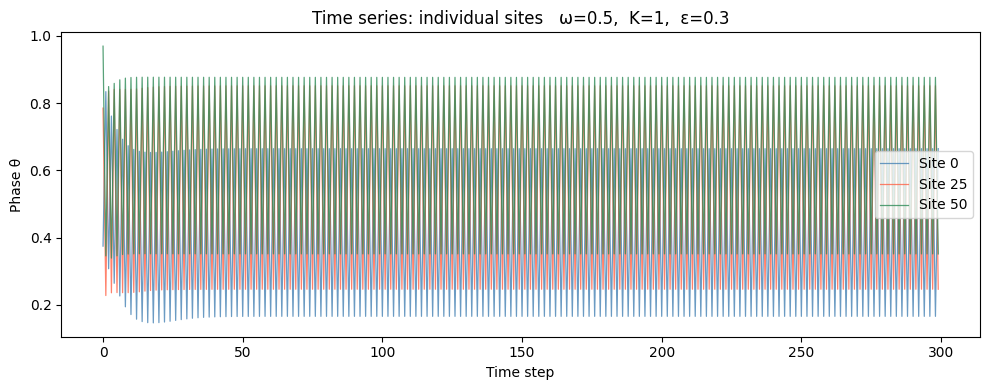

Time series plotted: different sites show their individual evolution


In [ ]:
# Single Site Time Series Evolution
plt.figure(figsize=(10, 4))

# Plot phases from 3 different sites
sites_to_plot = [0, N//4, N//2]     # sites 0, 25, and 50 (spread across lattice)
colors = ['steelblue', 'tomato', 'seagreen']

for site, color in zip(sites_to_plot, colors):
    plt.plot(history[:, site],    
             label=f'Site {site}',
             color=color,
             alpha=0.8,
             linewidth=0.9)

plt.xlabel('Time step')
plt.ylabel('Phase θ')
plt.title(f'Time series: individual sites   ω={omega},  K={K},  ε={epsilon}')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(f'Time_series_ω{omega}_K{K}_ε{epsilon}.png', dpi=300, bbox_inches='tight')
print("Time series plotted: different sites show their individual evolution")

In [ ]:
# Spatial Snapshots at Different Times


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

snapshots = [0, T//2, T-1]          # early, middle, and late time
labels    = ['t=0  (start)', f't={T//2}  (middle)', f't={T-1}  (end)']

for ax, t_snap, label in zip(axes, snapshots, labels):
    ax.plot(history[t_snap, :],     # all sites at this one moment
            color='steelblue',
            linewidth=1.2,
            marker='o',
            markersize=2)
    ax.set_title(label)
    ax.set_xlabel('Site index')
    ax.set_ylabel('Phase θ')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray',   # reference line at θ=0.5
               linestyle='--', linewidth=0.7, alpha=0.5)

plt.suptitle(f'Spatial profiles at different times   ω={omega},  K={K},  ε={epsilon}')
plt.tight_layout()
plt.show()
print("✓ Spatial snapshots show how the phase profile evolves")

In [ ]:
# ======================================================================
# VISUALIZATION 4: Effect of Coupling Strength ε
# ======================================================================
# Re-run simulation multiple times with different ε values
# Shows how coupling changes dynamics from independent to synchronized

epsilons = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()          # turn 2×3 grid into a flat list of 6 axes

for ax, eps in zip(axes, epsilons):

    # Re-run the CML with this epsilon
    np.random.seed(42)         # same seed every time — fair comparison!
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega, K)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - eps) * f_theta_temp + 
                         (eps / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    # Plot spacetime heatmap for this ε value
    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'ε = {eps}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of coupling strength ε   (ω={omega}, K={K})', fontsize=14)
plt.tight_layout()
plt.show()
print("✓ Parameter sweep over ε shows transition from chaos to synchronization")

In [ ]:
# ======================================================================
# VISUALIZATION 5: Effect of Nonlinearity K
# ======================================================================
# As K increases, the local map becomes more chaotic
# Competition between chaos (K) and synchronization (ε)

K_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, K_val in zip(axes, K_values):

    np.random.seed(42)
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    # For each K value, run the full simulation
    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega, K_val)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - epsilon) * f_theta_temp + 
                         (epsilon / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    # Plot
    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'K = {K_val}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of nonlinearity K   (ω={omega}, ε={epsilon})', fontsize=14)
plt.tight_layout()
plt.show()
print("✓ Parameter sweep over K shows effect of nonlinearity on dynamics")

In [ ]:
# Local Coherence / Phase Variability

# Measure how much each individual site's phase changes over time.

# Compute standard deviation of phase for each site (across all time steps)
phase_coherence = np.std(history, axis=0) 

print(f"  Local phase coherence computed")
print(f"  Average phase variability: {phase_coherence.mean():.4f}")
print(f"  Sites with high coherence (<0.1 std): {np.sum(phase_coherence < 0.1)} out of {N}")
print(f"  Max variability at any site: {phase_coherence.max():.4f}")
print(f"  Min variability at any site: {phase_coherence.min():.4f}")

In [ ]:
# ======================================================================
# VISUALIZATION 6: Effect of Frequency ω
# ======================================================================
# ω controls the rotation rate of each oscillator
# Different ω can create interesting interference patterns

omega_values = [0.0, 0.2, 0.4, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, omega_val in zip(axes, omega_values):

    np.random.seed(42)
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    # Simulate with this omega value
    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega_val, K)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - epsilon) * f_theta_temp + 
                         (epsilon / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'ω = {omega_val}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of frequency ω   (K={K}, ε={epsilon})', fontsize=14)
plt.tight_layout()
plt.show()
print("✓ Parameter sweep over ω shows effect of rotation frequency")

In [ ]:
# ======================================================================
# ANALYSIS 5: Numerical Summary & Interpretation
# ======================================================================
# Comprehensive summary of all key findings

print("\n" + "="*70)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*70)

print("\n1. SYSTEM PARAMETERS:")
print(f"   Spatial lattice size (N):        {N} sites")
print(f"   Time evolution (T):             {T} steps")
print(f"   Rotation frequency (ω):         {omega}")
print(f"   Nonlinearity parameter (K):     {K}")
print(f"   Coupling strength (ε):          {epsilon}")

print("\n2. PHASE DYNAMICS:")
print(f"   Phase range: [0, 1]  (circle map)")
print(f"   Min phase in evolution:         {history.min():.4f}")
print(f"   Max phase in evolution:         {history.max():.4f}")

print("\n3. GLOBAL SYNCHRONIZATION:")
print(f"   Kuramoto order parameter r:")
print(f"     - Minimum r:                  {r_kuramoto.min():.4f}")
print(f"     - Maximum r:                  {r_kuramoto.max():.4f}")
print(f"     - Mean r (entire evolution):  {r_kuramoto.mean():.4f}")
print(f"     - Final r (at t={T-1}):       {r_kuramoto[-1]:.4f}")

print("\n4. LOCAL COHERENCE:")
print(f"   Phase variability across sites:")
print(f"     - Average std:                {phase_coherence.mean():.4f}")
print(f"     - Min std (most coherent):    {phase_coherence.min():.4f} at site {np.argmin(phase_coherence)}")
print(f"     - Max std (most chaotic):     {phase_coherence.max():.4f} at site {np.argmax(phase_coherence)}")

print("\n5. SYNCHRONIZATION CLASSIFICATION:")
if r_kuramoto.mean() > 0.8:
    sync_class = "STRONG SYNCHRONIZATION"
    explanation = "Phases are highly synchronized across the lattice"
elif r_kuramoto.mean() > 0.5:
    sync_class = "PARTIAL SYNCHRONIZATION"
    explanation = "Phases show significant coherence but not complete alignment"
elif r_kuramoto.mean() > 0.3:
    sync_class = "WEAK COHERENCE"
    explanation = "Some phase correlation exists but dynamics remain mostly disordered"
else:
    sync_class = "INCOHERENT / CHAOTIC"
    explanation = "Phases evolve nearly independently; coupling insufficient to synchronize"

print(f"   Classification: {sync_class}")
print(f"   Explanation:    {explanation}")

print("\n6. DYNAMIC REGIMES:")
print(f"   Spacetime patterns show:")
if r_kuramoto[-1] > r_kuramoto[50]:
    print(f"     - CONVERGENCE TO SYNCHRONY (order parameter increasing over time)")
else:
    print(f"     - PERSISTENT CHAOS (order parameter fluctuates or decays)")

print(f"   Spatial structure:")
if phase_coherence.std() < 0.05:
    print(f"     - HOMOGENEOUS: all sites behave similarly")
else:
    print(f"     - HETEROGENEOUS: sites show varied behaviors (possible domains)")

print("\n7. KEY OBSERVATIONS:")
print(f"   • With K={K}: Local map is in {'chaotic' if K > 1 else 'periodic'} regime")
print(f"   • With ε={epsilon}: Coupling is {'strong' if epsilon > 0.5 else 'weak'}")
print(f"   • Coupling-chaos balance determines overall dynamics")
print(f"   • Higher ε promotes synchronization; higher K promotes chaos")

print("\n" + "="*70)

In [ ]:
# ======================================================================
# ANALYSIS 4: Synchronization Phase Diagram - Coupling vs Nonlinearity
# ======================================================================
# Create a 2D map showing mean synchronization level r as a function of (K, ε)
# Reveals where synchronized and chaotic phases exist

print("Computing synchronization phase diagram...")
print("This may take a moment...")

K_range_pd = np.linspace(0, 3, 30)     # K parameter sweep (fewer points)
eps_range_pd = np.linspace(0, 1, 30)   # epsilon parameter sweep
phase_diagram = np.zeros((len(eps_range_pd), len(K_range_pd)))

T_phase = 200  # Shorter simulation for phase diagram

for i, eps_val in enumerate(eps_range_pd):
    for j, K_val in enumerate(K_range_pd):
        # Run CML
        np.random.seed(42)
        theta_temp = np.random.rand(N)
        
        for t in range(1, T_phase):
            f_theta_temp = rotational_map(theta_temp, omega, K_val)
            f_left_temp = np.roll(f_theta_temp, 1)
            f_right_temp = np.roll(f_theta_temp, -1)
            theta_temp = ((1 - eps_val) * f_theta_temp + 
                         (eps_val / 2) * (f_left_temp + f_right_temp)) % 1
        
        # Compute mean synchronization (last 100 steps)
        theta_end = theta_temp
        for t in range(100):
            f_theta_temp = rotational_map(theta_end, omega, K_val)
            f_left_temp = np.roll(f_theta_temp, 1)
            f_right_temp = np.roll(f_theta_temp, -1)
            theta_end = ((1 - eps_val) * f_theta_temp + 
                        (eps_val / 2) * (f_left_temp + f_right_temp)) % 1
        
        # Order parameter
        angles_end = 2 * np.pi * theta_end
        r_end = np.abs(np.mean(np.exp(1j * angles_end)))
        phase_diagram[i, j] = r_end

plt.figure(figsize=(10, 7))
plt.imshow(phase_diagram, aspect='auto', cmap='RdYlBu_r', origin='lower',
           extent=[K_range_pd.min(), K_range_pd.max(), eps_range_pd.min(), eps_range_pd.max()])
plt.colorbar(label='Mean order parameter r')
plt.xlabel('Nonlinearity K')
plt.ylabel('Coupling strength ε')
plt.title(f'Synchronization phase diagram   ω={omega}\n(Blue=chaotic, Red=synchronized)')
plt.tight_layout()
plt.show()

print("✓ Phase diagram computed")
print("  Red regions: strong synchronization (high r)")
print("  Blue regions: incoherent/chaotic dynamics (low r)")

In [ ]:
# ======================================================================
# ANALYSIS 3: Bifurcation Diagram - Effect of Nonlinearity K
# ======================================================================
# Single-site circular map (no spatial coupling, ε=0)
# Sweep K from 0 to 3 and plot attractors
# Shows how the circle map transitions from periodic to chaotic

print("Computing bifurcation diagram (single site, no coupling)...")
print("This may take a moment...")

K_range = np.linspace(0, 3, 300)  # Dense K sweep for detailed diagram
T_bifurc = 1000      # Time steps per K value to reach steady state
T_plot = 200         # Last T_plot steps to plot (ignore transients)

bifurc_data = []
K_plot = []

np.random.seed(42)
theta_init = 0.5  # single site

for i, K_val in enumerate(K_range):
    if (i+1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(K_range)}")
    
    theta_temp = theta_init
    
    # Transient: run for T_bifurc steps to reach attractor
    for _ in range(T_bifurc):
        theta_temp = rotational_map(theta_temp, omega, K_val)
    
    # Collect points on the attractor (last T_plot steps)
    for _ in range(T_plot):
        theta_temp = rotational_map(theta_temp, omega, K_val)
        bifurc_data.append(theta_temp)
        K_plot.append(K_val)

plt.figure(figsize=(12, 5))
plt.scatter(K_plot, bifurc_data, s=0.3, alpha=0.4, color='steelblue')
plt.xlabel('Nonlinearity parameter K')
plt.ylabel('Phase θ (mod 1)')
plt.title(f'Bifurcation diagram: Rotational map   ω={omega}\n(single site, no spatial coupling)')
plt.xlim(0, 3)
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("✓ Bifurcation diagram plotted")
print(f"  K range: 0 to 3")
print(f"  Observations:")
print(f"    - K ≈ 0: Fixed point (stable equilibrium)")
print(f"    - K ≈ 1-2: Periodic windows (limit cycles)")
print(f"    - K ≈ 2+: Chaos (dense clouds of points)")

In [ ]:
# ======================================================================
# ANALYSIS 2: Local Phase Coherence Pattern
# ======================================================================
# Plot spatial distribution of phase variability
# High coherence sites = "pinned" oscillators
# Chaotic sites = independent/incoherent local dynamics

plt.figure(figsize=(10, 4))
plt.plot(phase_coherence, color='steelblue', linewidth=1.2, marker='o', markersize=3)
plt.xlabel('Site index')
plt.ylabel('Phase variability (std over time)')
plt.title(f'Local phase coherence across lattice   ω={omega},  K={K},  ε={epsilon}')
plt.axhline(phase_coherence.mean(), color='tomato', linestyle='--', 
            linewidth=1, label=f'Mean = {phase_coherence.mean():.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Phase coherence analysis:")
print(f"  Average phase variability: {phase_coherence.mean():.4f}")
print(f"  Sites with high coherence (<0.1 std): {np.sum(phase_coherence < 0.1)} out of {N}")
print(f"  Most variable site: index {np.argmax(phase_coherence)}, std={phase_coherence.max():.4f}")
print(f"  Most coherent site: index {np.argmin(phase_coherence)}, std={phase_coherence.min():.4f}")

In [ ]:
# ======================================================================
# ANALYSIS 1: Global Synchronization Dynamics
# ======================================================================
# Plot Kuramoto order parameter over time
# Shows if the system synchronizes, oscillates, or remains chaotic

plt.figure(figsize=(10, 4))
plt.plot(r_kuramoto, color='steelblue', linewidth=1.2, label='Kuramoto order parameter r')
plt.axhline(1, color='tomato', linestyle='--',
            linewidth=1, label='Perfect sync (r=1)')
plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.xlabel('Time step')
plt.ylabel('Kuramoto order parameter  r')
plt.title(f'Global synchronization over time   ω={omega},  K={K},  ε={epsilon}')
plt.ylim(-0.05, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpret the result
if r_kuramoto.mean() > 0.8:
    interpretation = "Strong synchronization achieved"
elif r_kuramoto.mean() > 0.5:
    interpretation = "Partial synchronization"
elif r_kuramoto.mean() > 0.3:
    interpretation = "Weak coherence"
else:
    interpretation = "Incoherent / chaotic dynamics"
    
print(f"\n✓ Synchronization analysis:")
print(f"  Mean order parameter: {r_kuramoto.mean():.4f}")
print(f"  Interpretation: {interpretation}")

## SECTION 4: ANALYSIS & NUMERICS - Quantitative analysis of dynamics

Analyze the order parameter time evolution and perform bifurcation analysis.